In [1]:
import random
import string
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

pd.options.display.max_columns = None

label_dict = {i: c for i, c in enumerate(string.ascii_uppercase[:25])}

In [2]:
train_base = pd.read_csv("./sign/sign_mnist_train.csv")
test_base = pd.read_csv("./sign/sign_mnist_test.csv")

In [3]:
# 目的変数y / 説明変数X
y_train = train_base['label'].values
X_train = train_base.drop(columns='label').values.reshape(len(train_base), 28, 28, 1)
y_test  = test_base['label'].values
X_test  = test_base.drop(columns='label').values.reshape(len(test_base), 28, 28, 1)

# 検証データを用意(割合はtestデータと同じ)
size = len(test_base) / (len(train_base) + len(test_base))
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=size, random_state=0)

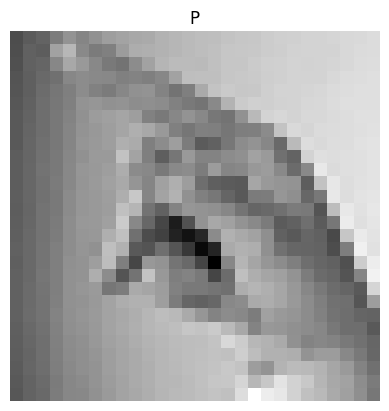

In [4]:
# （任意）可視化：ランダム1枚
rand_num = random.randint(0, len(X_train)-1)
plt.imshow(X_train[rand_num].squeeze(), cmap='gray')
plt.title(label_dict[y_train[rand_num]])
plt.axis('off')
plt.show()

In [5]:
# One-hotエンコード
y_train = tf.one_hot(y_train, 25)
y_valid = tf.one_hot(y_valid, 25)
y_test = tf.one_hot(y_test, 25)

# データの確認
print(f"y_train={y_train.shape}, y_valid={y_valid.shape}, y_test={y_test.shape}")
print(f"X_train={X_train.shape}, X_valid={X_valid.shape}, X_test={X_test.shape}")

y_train=(21768, 25), y_valid=(5687, 25), y_test=(7172, 25)
X_train=(21768, 28, 28, 1), X_valid=(5687, 28, 28, 1), X_test=(7172, 28, 28, 1)


In [6]:
# 1つ目のモデル:自作CNN
model1 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, kernel_size=3, padding="same", strides=1, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(64, kernel_size=3, padding="same", strides=1, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128, kernel_size=3, padding="same", strides=1, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(25, activation='softmax')
])

model1.compile(optimizer="adam", loss="categorical_crossentropy", metrics=['accuracy'])

In [7]:
%%time
# 学習の実施（1つ目のモデル）
log1 = model1.fit(X_train, y_train, epochs=50, batch_size=64, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)],
                validation_data=(X_valid, y_valid))

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.4537 - loss: 1.7483 - val_accuracy: 0.0823 - val_loss: 7.7636
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8814 - loss: 0.3763 - val_accuracy: 0.8022 - val_loss: 0.6567
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9533 - loss: 0.1691 - val_accuracy: 0.9349 - val_loss: 0.2283
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9704 - loss: 0.1125 - val_accuracy: 0.9865 - val_loss: 0.0588
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9793 - loss: 0.0841 - val_accuracy: 0.9982 - val_loss: 0.0240
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9825 - loss: 0.0726 - val_accuracy: 0.9478 - val_loss: 0.1670
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9878 - loss: 0.0573 - val_accuracy: 0.9938 - val_loss: 0.0349
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9896 - loss: 0.0488 - val_acc

Text(0, 0.5, 'crossentropy')

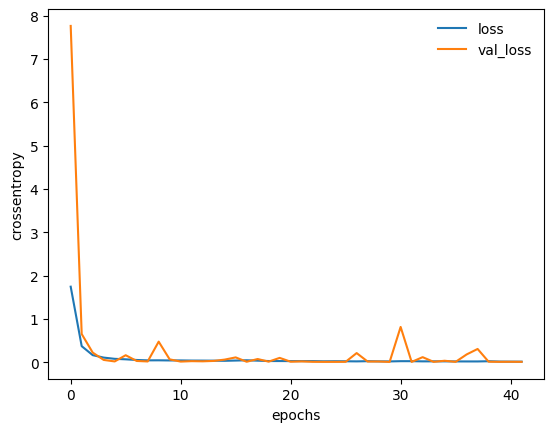

In [8]:
# 学習曲線（1つ目のモデル）
plt.plot(log1.history['loss'], label='loss')
plt.plot(log1.history['val_loss'], label='val_loss')
plt.legend(frameon=False)
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [9]:
# 2つ目のモデル:MobileNetV3
inputs = tf.keras.Input(shape=(28, 28, 1))

x = tf.keras.layers.Resizing(224, 224)(inputs)
x = tf.keras.layers.Lambda(lambda t: tf.image.grayscale_to_rgb(t))(x) 

x = tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input)(x)

base = tf.keras.applications.MobileNetV3Small(
    include_top=False,
    weights='imagenet',
    input_tensor=x,
    pooling='avg'
)

base.trainable = False

h = tf.keras.layers.Dropout(0.3)(base.output)
h = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)
h = tf.keras.layers.Dropout(0.4)(h)
outputs = tf.keras.layers.Dense(25, activation='softmax')(h)

model2 = tf.keras.models.Model(inputs=inputs, outputs=outputs)

model2.compile(optimizer = "adam", loss="categorical_crossentropy", metrics=['accuracy'])

In [10]:
%%time
# 学習の実施（2つ目のモデル）
log2 = model2.fit(X_train, y_train, epochs=50, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=50, verbose=1)],
                validation_data=(X_valid, y_valid))

Epoch 1/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 86s 121ms/step - accuracy: 0.5690 - loss: 1.4045 - val_accuracy: 0.9437 - val_loss: 0.3157
Epoch 2/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 83s 122ms/step - accuracy: 0.8382 - loss: 0.5218 - val_accuracy: 0.9872 - val_loss: 0.1405
Epoch 3/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 83s 122ms/step - accuracy: 0.8898 - loss: 0.3688 - val_accuracy: 0.9938 - val_loss: 0.1066
Epoch 4/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 87s 128ms/step - accuracy: 0.9138 - loss: 0.3027 - val_accuracy: 0.9949 - val_loss: 0.0835
Epoch 5/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 87s 128ms/step - accuracy: 0.9259 - loss: 0.2692 - val_accuracy: 0.9995 - val_loss: 0.0716
Epoch 6/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 86s 127ms/step - accuracy: 0.9354 - loss: 0.2471 - val_accuracy: 0.9991 - val_loss: 0.0702
Epoch 7/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 90s 132ms/step - accuracy: 0.9413 - loss: 0.2289 - val_accuracy: 0.9991 - val_loss: 0.0678
Epoch 8/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 87s 128ms/step - accuracy: 0.9447 - loss: 0

Text(0, 0.5, 'crossentropy')

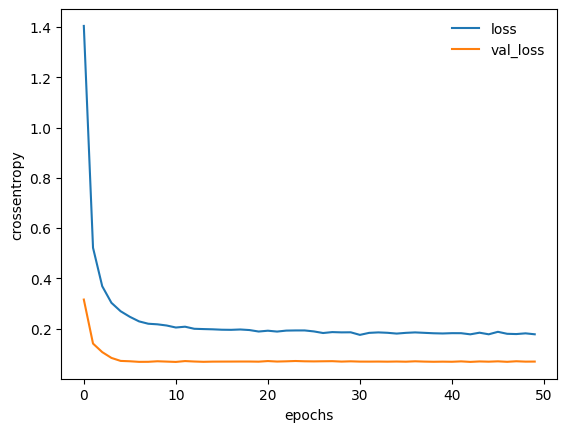

In [11]:
# 学習曲線（2つ目のモデル）
plt.plot(log2.history['loss'], label='loss')
plt.plot(log2.history['val_loss'], label='val_loss')
plt.legend(frameon=False)
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [ ]:
# 予測
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step


In [30]:
# 平均（重み付け有）
pred_avg = 0.5*pred1 + 0.5*pred2

# 正解ラベル
y_test_idx = np.argmax(y_test.numpy(), axis=1)

In [31]:
# CNNの評価
print("== Model 1 (CNN) ==")
y_pred1 = np.argmax(pred1, axis=1)
print(classification_report(y_test_idx, y_pred1, digits=4))

== Model 1 (CNN) ==
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       331
           1     1.0000    1.0000    1.0000       432
           2     1.0000    1.0000    1.0000       310
           3     1.0000    1.0000    1.0000       245
           4     0.9579    0.9598    0.9589       498
           5     1.0000    1.0000    1.0000       247
           6     0.9971    1.0000    0.9986       348
           7     1.0000    0.9977    0.9989       436
           8     0.9965    1.0000    0.9983       288
          10     1.0000    0.9909    0.9954       331
          11     0.9952    1.0000    0.9976       209
          12     1.0000    1.0000    1.0000       394
          13     1.0000    0.9794    0.9896       291
          14     1.0000    1.0000    1.0000       246
          15     1.0000    1.0000    1.0000       347
          16     1.0000    1.0000    1.0000       164
          17     0.9796    1.0000    0.9897       144
       

In [32]:
# MobileNetV3の評価
print("== Model 2 (MobileNetV3Small) ==")
y_pred2 = np.argmax(pred2, axis=1)
print(classification_report(y_test_idx, y_pred2, digits=4))

== Model 2 (MobileNetV3Small) ==
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       331
           1     1.0000    1.0000    1.0000       432
           2     0.9936    1.0000    0.9968       310
           3     1.0000    0.9959    0.9980       245
           4     1.0000    0.9659    0.9826       498
           5     1.0000    1.0000    1.0000       247
           6     0.9886    1.0000    0.9943       348
           7     1.0000    0.9908    0.9954       436
           8     1.0000    0.9965    0.9983       288
          10     1.0000    1.0000    1.0000       331
          11     1.0000    1.0000    1.0000       209
          12     0.9563    1.0000    0.9777       394
          13     1.0000    0.9897    0.9948       291
          14     1.0000    0.9919    0.9959       246
          15     1.0000    1.0000    1.0000       347
          16     1.0000    1.0000    1.0000       164
          17     0.9931    1.0000    0.9965     

In [33]:
# アンサンブルの評価
print("== Ensemble (Average) ==")
y_pred_avg = np.argmax(pred_avg, axis=1)
print(classification_report(y_test_idx, y_pred_avg, digits=4))

== Ensemble (Average) ==
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       331
           1     1.0000    1.0000    1.0000       432
           2     1.0000    1.0000    1.0000       310
           3     1.0000    1.0000    1.0000       245
           4     1.0000    1.0000    1.0000       498
           5     1.0000    1.0000    1.0000       247
           6     1.0000    1.0000    1.0000       348
           7     1.0000    1.0000    1.0000       436
           8     1.0000    1.0000    1.0000       288
          10     1.0000    1.0000    1.0000       331
          11     1.0000    1.0000    1.0000       209
          12     1.0000    1.0000    1.0000       394
          13     1.0000    1.0000    1.0000       291
          14     1.0000    1.0000    1.0000       246
          15     1.0000    1.0000    1.0000       347
          16     1.0000    1.0000    1.0000       164
          17     1.0000    1.0000    1.0000       144
  